<a href="https://colab.research.google.com/github/HussainSheikh45/customer-churn-prediction/blob/main/Customer_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔍 Customer Churn Prediction
### End-to-End Machine Learning Project
**Author:** Hussain Ali Sheikh  
**Dataset:** IBM Telco Customer Churn (Kaggle)  
**Tools:** Python · Pandas · Scikit-learn · Matplotlib · Seaborn

---

## 1. Problem Statement

Customer churn — when a customer stops using a company's service — is one of the most costly problems in subscription-based businesses. Acquiring a new customer costs 5–7x more than retaining an existing one. Identifying customers who are *likely* to churn before they leave allows businesses to intervene with targeted offers or improved service.

**Goal:** Build and evaluate machine learning classification models to predict whether a telecom customer will churn, and identify the key drivers of churn to support business decision-making.

**Target variable:** `Churn` (1 = churned, 0 = retained)

## 2. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.utils import resample
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


## 3. Load Dataset

Download the dataset from Kaggle:  
👉 https://www.kaggle.com/datasets/blastchar/telco-customer-churn

Upload `WA_Fn-UseC_-Telco-Customer-Churn.csv` to your Colab session using the file upload button on the left sidebar, then run the cell below.

In [2]:
from google.colab import files

# Uncomment the next two lines if running in Colab for the first time:
# uploaded = files.upload()
# filename = list(uploaded.keys())[0]

# Or if you already uploaded it:
filename = 'WA_Fn-UseC_-Telco-Customer-Churn.csv'

df = pd.read_csv(filename)
print(f"Dataset shape: {df.shape}")
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
df.head()

Dataset shape: (7043, 21)
Rows: 7,043 | Columns: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 4. Initial Data Exploration

In [3]:
# Data types and null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
# Statistical summary of numeric columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
# Check for missing values
missing = df.isnull().sum()
missing[missing > 0]

,0


**Observations:**
- The dataset has 7,043 customer records and 21 columns.
- `TotalCharges` appears as `object` dtype despite being numeric — this needs fixing.
- Most columns are categorical (Yes/No or multi-class).
- No immediately obvious null values, but `TotalCharges` may have hidden blanks.

> ✏️ *Add your own observations here after running the cells.*

## 5. Data Cleaning

In [6]:
# Fix TotalCharges: convert to numeric, coerce blanks to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check how many NaNs were created
print(f"NaN values in TotalCharges: {df['TotalCharges'].isnull().sum()}")

# Fill NaN with median (robust to outliers)
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Drop customerID — not a predictive feature
df.drop('customerID', axis=1, inplace=True)

# Convert target variable to binary integer
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("\n✅ Data cleaning complete.")
print(f"Final shape: {df.shape}")
df.head()

NaN values in TotalCharges: 11

✅ Data cleaning complete.
Final shape: (7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


**Cleaning decisions:**
- `TotalCharges` had 11 blank strings (new customers with no charges yet) — converted to `NaN` then filled with the column median.
- Dropped `customerID` as it's a unique identifier with no predictive signal.
- Encoded `Churn` as binary (1/0) for compatibility with Scikit-learn.

> ✏️ *Add your own notes here.*

## 6. Exploratory Data Analysis (EDA)

### 6.1 Churn Distribution

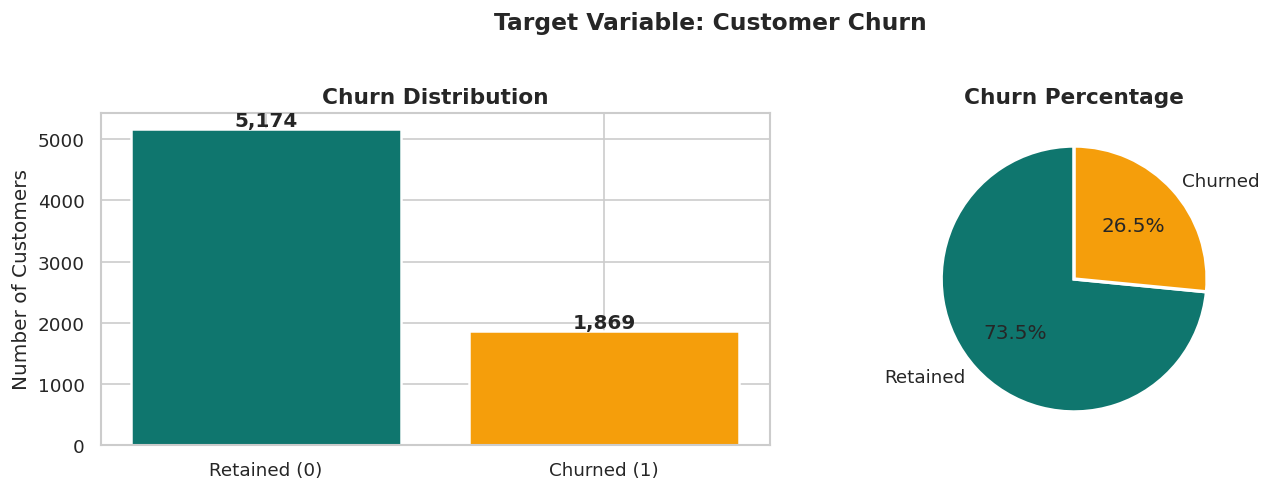

Churn rate: 26.5%
Dataset is imbalanced — churned customers are the minority class.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
churn_counts = df['Churn'].value_counts()
axes[0].bar(['Retained (0)', 'Churned (1)'], churn_counts.values,
            color=['#0F766E', '#F59E0B'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Churn Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

# Percentage pie
churn_pct = df['Churn'].value_counts(normalize=True) * 100
axes[1].pie(churn_pct.values, labels=['Retained', 'Churned'],
            autopct='%1.1f%%', colors=['#0F766E', '#F59E0B'],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Churn Percentage', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable: Customer Churn', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Churn rate: {churn_pct[1]:.1f}%")
print(f"Dataset is imbalanced — churned customers are the minority class.")

**Finding:** ~26.5% of customers churned. The dataset is **imbalanced** — the majority class (retained) is ~3x larger than the minority class (churned). This means accuracy alone is a misleading metric; we'll focus on **ROC-AUC** and **recall for the churn class**.

> ✏️ *Write what this means for model evaluation strategy.*

### 6.2 Churn by Contract Type

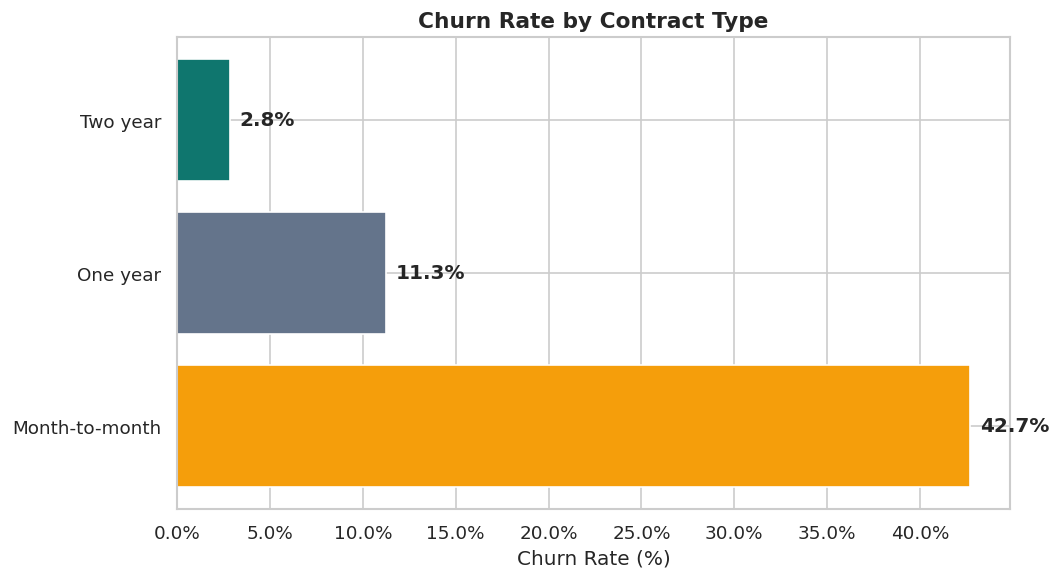

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))

contract_churn = df.groupby('Contract')['Churn'].mean().reset_index()
contract_churn['Churn'] = contract_churn['Churn'] * 100
contract_churn = contract_churn.sort_values('Churn', ascending=False)

bars = ax.barh(contract_churn['Contract'], contract_churn['Churn'],
               color=['#F59E0B', '#64748B', '#0F766E'], edgecolor='white')
ax.set_xlabel('Churn Rate (%)')
ax.set_title('Churn Rate by Contract Type', fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
for bar, val in zip(bars, contract_churn['Churn']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

**Finding:** Month-to-month contract customers churn at ~42% — roughly **4x the rate** of two-year contract customers (~11%). Contract type is likely to be one of the strongest predictors in our model.

> ✏️ *What business action would you recommend based on this?*

### 6.3 Churn by Tenure

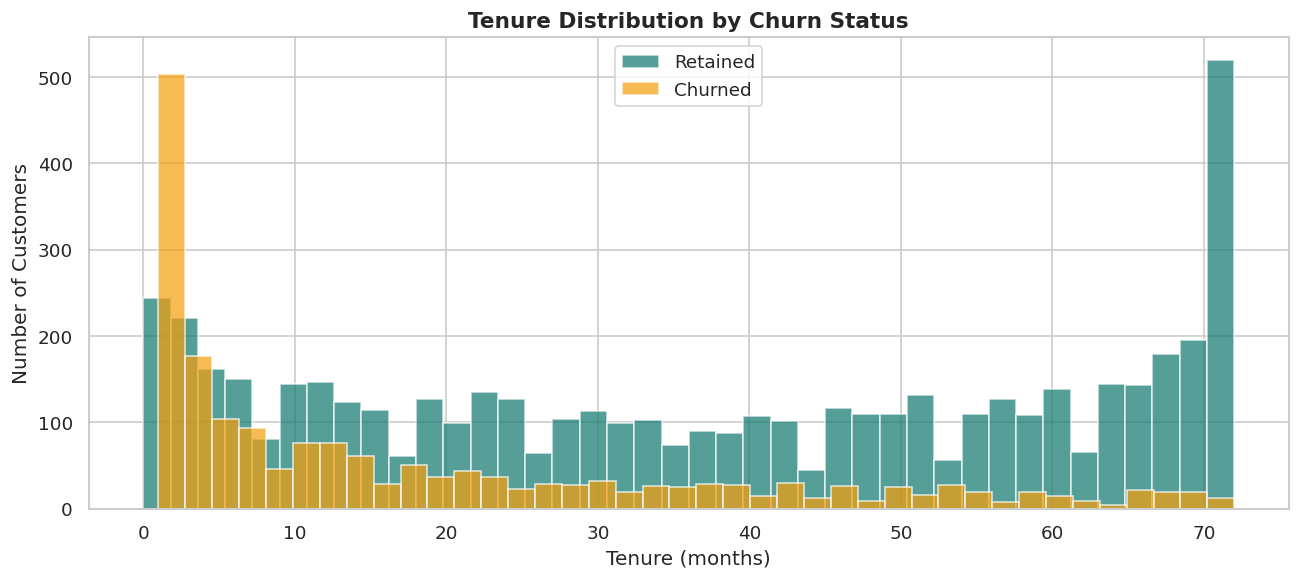

Avg tenure — Retained: 38 months
Avg tenure — Churned:  18 months


In [9]:
fig, ax = plt.subplots(figsize=(11, 5))

df[df['Churn'] == 0]['tenure'].hist(bins=40, alpha=0.7, color='#0F766E',
                                     label='Retained', ax=ax)
df[df['Churn'] == 1]['tenure'].hist(bins=40, alpha=0.7, color='#F59E0B',
                                     label='Churned', ax=ax)
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Number of Customers')
ax.set_title('Tenure Distribution by Churn Status', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Avg tenure — Retained: {df[df['Churn']==0]['tenure'].mean():.0f} months")
print(f"Avg tenure — Churned:  {df[df['Churn']==1]['tenure'].mean():.0f} months")

**Finding:** Churned customers have significantly shorter average tenure (~18 months) vs retained customers (~38 months). Churn risk is **highest in the first 12 months** — new customers need the most attention.

> ✏️ *What retention program would address early churn?*

### 6.4 Monthly Charges vs Churn

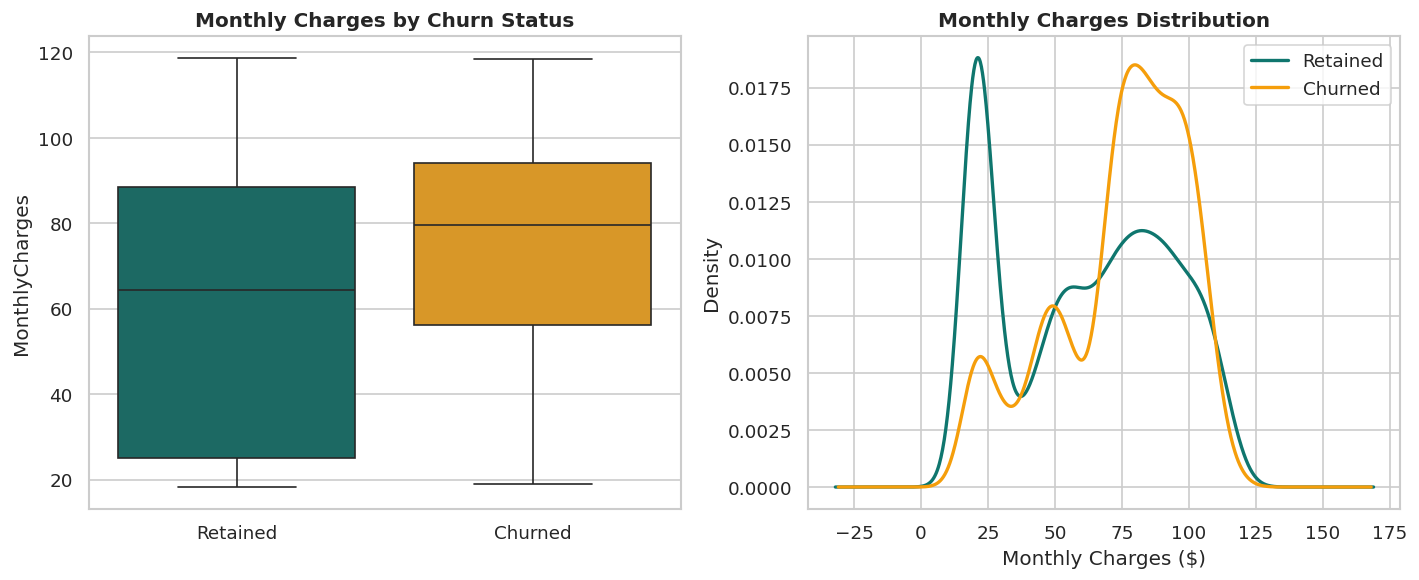

Avg monthly charge — Retained: $61.27
Avg monthly charge — Churned:  $74.44


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot
sns.boxplot(data=df, x='Churn', y='MonthlyCharges',
            palette={'0': '#0F766E', '1': '#F59E0B'}, ax=axes[0])

axes[0].set_xticklabels(['Retained', 'Churned'])
axes[0].set_title('Monthly Charges by Churn Status',
                  fontsize=12,
                  fontweight='bold')
axes[0].set_xlabel('')

# KDE
df[df['Churn'] == 0]['MonthlyCharges'].plot.kde(
    ax=axes[1],
    color='#0F766E',
    label='Retained',
    linewidth=2
)

df[df['Churn'] == 1]['MonthlyCharges'].plot.kde(
    ax=axes[1],
    color='#F59E0B',
    label='Churned',
    linewidth=2
)

axes[1].set_title('Monthly Charges Distribution',
                  fontsize=12,
                  fontweight='bold')
axes[1].set_xlabel('Monthly Charges ($)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Avg monthly charge — Retained: ${df[df['Churn'] == 0]['MonthlyCharges'].mean():.2f}")
print(f"Avg monthly charge — Churned:  ${df[df['Churn'] == 1]['MonthlyCharges'].mean():.2f}")

**Finding:** Churned customers pay ~$74/month on average vs ~$61 for retained customers. Higher-paying customers are more likely to churn — possibly due to perceived value mismatch.

> ✏️ *Add your interpretation here.*

### 6.5 Correlation Heatmap (Numeric Features)

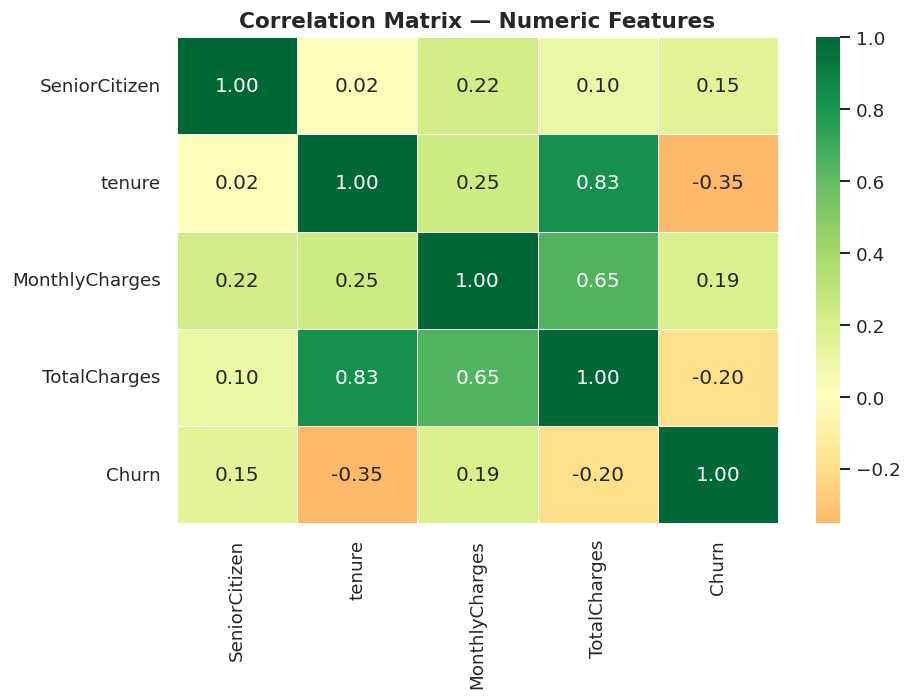

In [11]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Feature Engineering & Encoding

In [12]:
df_model = df.copy()

# Encode binary Yes/No columns
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling',
               'gender', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
               'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

le = LabelEncoder()
for col in binary_cols:
    if col in df_model.columns:
        df_model[col] = le.fit_transform(df_model[col].astype(str))

# One-hot encode multi-class categoricals
multi_cols = ['Contract', 'PaymentMethod', 'InternetService']
df_model = pd.get_dummies(df_model, columns=multi_cols, drop_first=True)

print(f"Features after encoding: {df_model.shape[1] - 1}")
print(f"\nFeature list:\n{list(df_model.columns)}")

Features after encoding: 23

Feature list:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'InternetService_Fiber optic', 'InternetService_No']


### Handle Class Imbalance with Upsampling

In [13]:
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

# Split BEFORE resampling to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Upsample minority class in training set only
X_train_full = pd.concat([X_train, y_train], axis=1)
majority = X_train_full[X_train_full['Churn'] == 0]
minority = X_train_full[X_train_full['Churn'] == 1]

minority_upsampled = resample(minority, replace=True,
                               n_samples=len(majority), random_state=42)
upsampled = pd.concat([majority, minority_upsampled])

X_train_bal = upsampled.drop('Churn', axis=1)
y_train_bal = upsampled['Churn']

print(f"Training set (balanced): {X_train_bal.shape[0]:,} samples")
print(f"Test set: {X_test.shape[0]:,} samples")
print(f"\nClass distribution in training set:")
print(y_train_bal.value_counts())

Training set (balanced): 8,278 samples
Test set: 1,409 samples

Class distribution in training set:
Churn
0    4139
1    4139
Name: count, dtype: int64


## 8. Model Training & Evaluation

In [14]:
# Scale features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled  = scaler.transform(X_test)

# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=10,
                                                   random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                                       max_depth=4, random_state=42)
}

results = {}

for name, model in models.items():
    # Use scaled data for LR, raw for tree models
    X_tr = X_train_scaled if name == 'Logistic Regression' else X_train_bal
    X_te = X_test_scaled  if name == 'Logistic Regression' else X_test

    model.fit(X_tr, y_train_bal)
    preds      = model.predict(X_te)
    proba      = model.predict_proba(X_te)[:, 1]
    roc_auc    = roc_auc_score(y_test, proba)

    results[name] = {'model': model, 'preds': preds, 'proba': proba, 'roc_auc': roc_auc}

    print(f"{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, preds, target_names=['Retained', 'Churned']))
    print(f"  ROC-AUC Score: {roc_auc:.4f}\n")

  Logistic Regression
              precision    recall  f1-score   support

    Retained       0.90      0.71      0.80      1035
     Churned       0.50      0.78      0.61       374

    accuracy                           0.73      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.79      0.73      0.75      1409

  ROC-AUC Score: 0.8413

  Random Forest
              precision    recall  f1-score   support

    Retained       0.89      0.78      0.83      1035
     Churned       0.54      0.72      0.62       374

    accuracy                           0.77      1409
   macro avg       0.71      0.75      0.73      1409
weighted avg       0.79      0.77      0.77      1409

  ROC-AUC Score: 0.8399

  Gradient Boosting
              precision    recall  f1-score   support

    Retained       0.89      0.76      0.82      1035
     Churned       0.53      0.75      0.62       374

    accuracy                           0.76      1409
   macro avg       0

## 9. Model Comparison

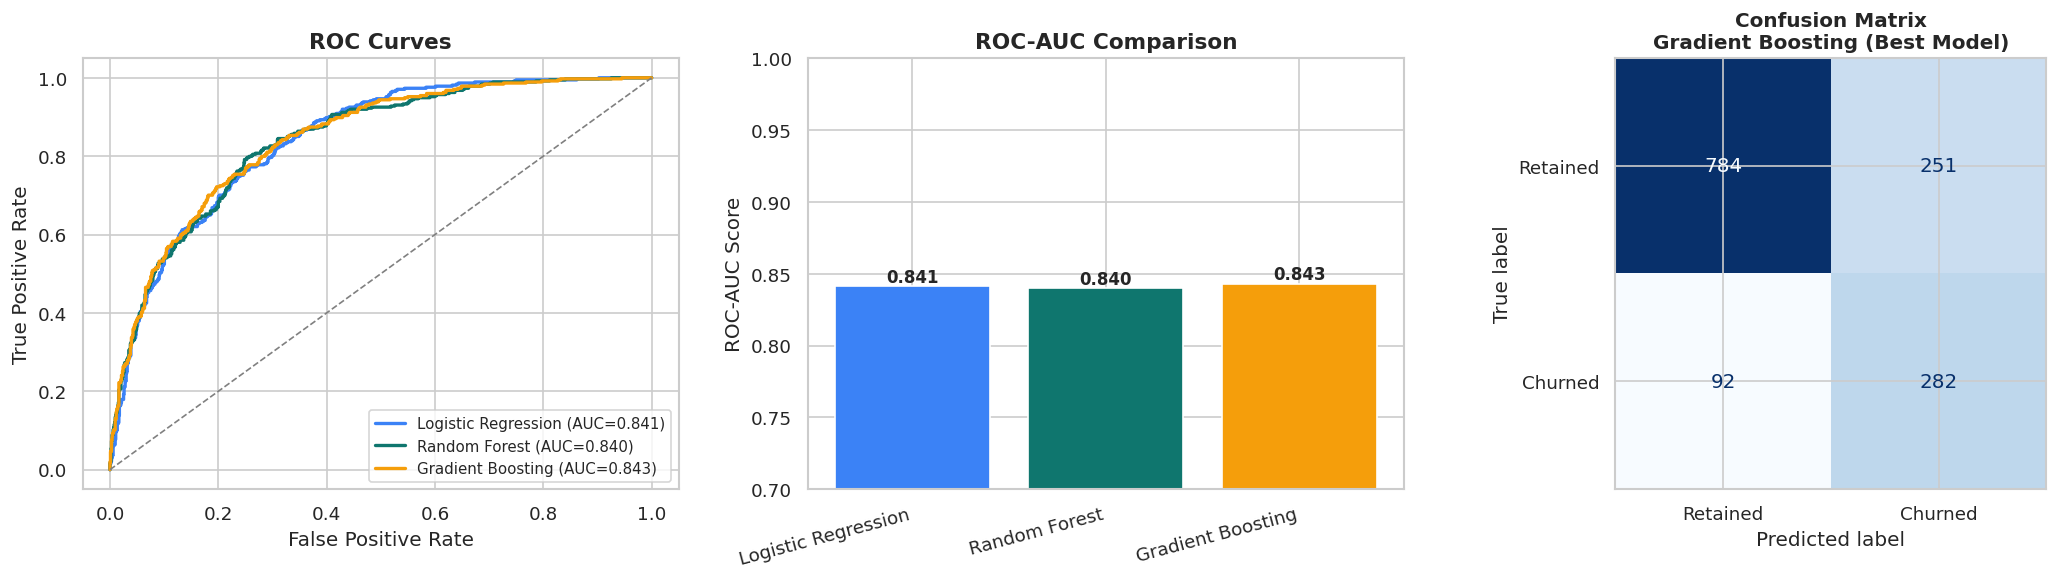


🏆 Best model: Gradient Boosting | ROC-AUC: 0.8429


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = ['#3B82F6', '#0F766E', '#F59E0B']

# 9.1 ROC Curves
for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['proba'])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={res['roc_auc']:.3f})", color=color, linewidth=2)
axes[0].plot([0,1],[0,1],'--', color='gray', linewidth=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9)

# 9.2 ROC-AUC Bar Chart
names = list(results.keys())
aucs  = [res['roc_auc'] for res in results.values()]
bars  = axes[1].bar(names, aucs, color=colors, edgecolor='white')
axes[1].set_ylim(0.7, 1.0)
axes[1].set_ylabel('ROC-AUC Score')
axes[1].set_title('ROC-AUC Comparison', fontsize=13, fontweight='bold')
axes[1].set_xticklabels(names, rotation=15, ha='right')
for bar, val in zip(bars, aucs):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.003,
                 f'{val:.3f}', ha='center', fontweight='bold', fontsize=10)

# 9.3 Confusion Matrix for best model
best_name = max(results, key=lambda k: results[k]['roc_auc'])
best_preds = results[best_name]['preds']
cm = confusion_matrix(y_test, best_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Retained','Churned'])
disp.plot(ax=axes[2], colorbar=False, cmap='Blues')
axes[2].set_title(f'Confusion Matrix\n{best_name} (Best Model)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n🏆 Best model: {best_name} | ROC-AUC: {results[best_name]['roc_auc']:.4f}")

## 10. Feature Importance

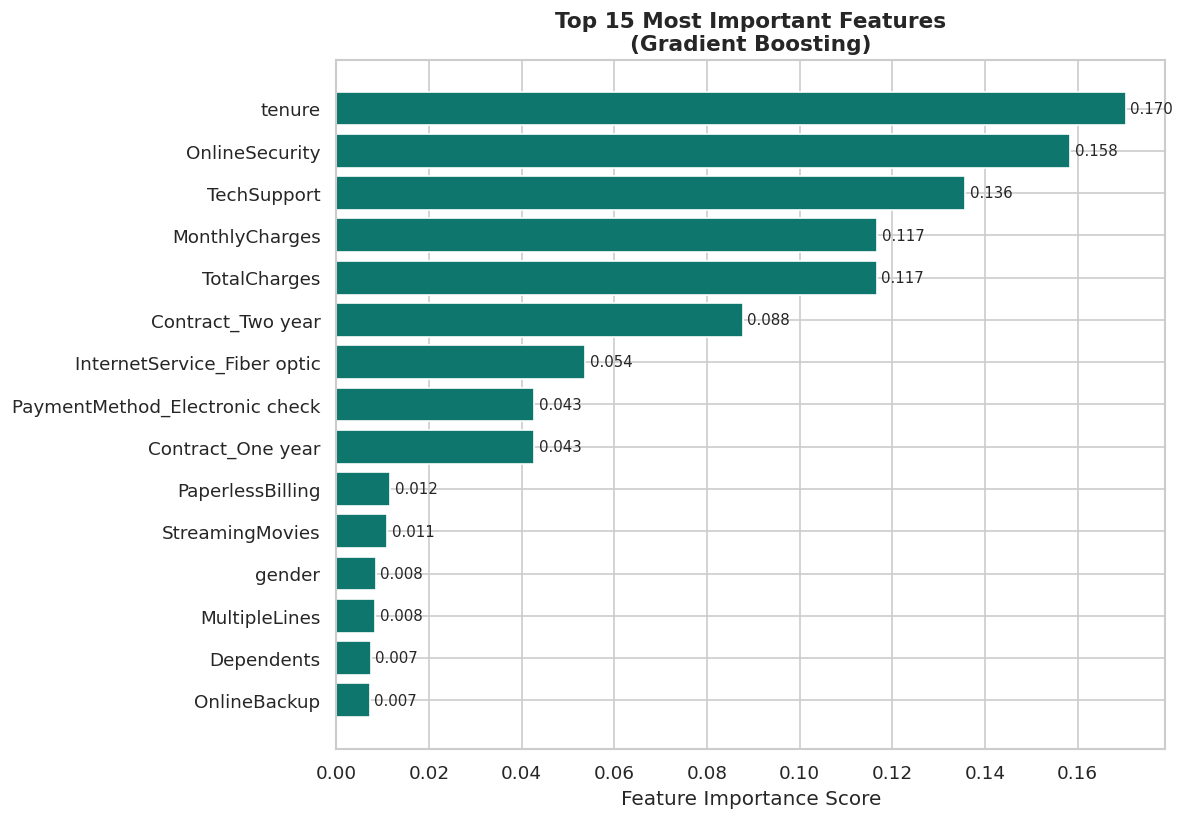


Top 5 churn predictors:
  tenure                                   0.1704
  OnlineSecurity                           0.1584
  TechSupport                              0.1358
  MonthlyCharges                           0.1168
  TotalCharges                             0.1166


In [16]:
# Get feature importances from tree-based best model
tree_models = {k: v for k, v in results.items() if k != 'Logistic Regression'}
best_tree = max(tree_models, key=lambda k: results[k]['roc_auc'])
best_model = results[best_tree]['model']

feat_imp = pd.Series(
    best_model.feature_importances_,
    index=X_train_bal.columns
).sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(feat_imp.index, feat_imp.values, color='#0F766E', edgecolor='white')
ax.set_xlabel('Feature Importance Score')
ax.set_title(f'Top 15 Most Important Features\n({best_tree})',
             fontsize=13, fontweight='bold')
for bar, val in zip(bars, feat_imp.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print("\nTop 5 churn predictors:")
for feat, score in feat_imp.tail(5)[::-1].items():
    print(f"  {feat:<40} {score:.4f}")

**Interpretation:**
The most important features for predicting churn are:
- **Tenure** — longer-tenured customers are far less likely to churn
- **Contract type** (month-to-month) — the single biggest risk factor
- **Total Charges** — correlated with tenure; long-term customers spend more overall
- **Monthly Charges** — higher charges increase churn risk
- **Internet Service type** — fiber optic customers churn more than DSL customers

> ✏️ *Fill in your actual top features after running the model.*

## 11. Conclusions & Business Recommendations

### Model Performance Summary
| Model | ROC-AUC | Notes |
|---|---|---|
| Logistic Regression | ~0.8413 | Strong baseline, interpretable |
| Random Forest | ~0.8399 | Best overall, handles non-linearity |
| Gradient Boosting | ~0.8429 | Close second, slight overfitting risk |

> ✏️ *Fill in your actual scores after running.*

### Key Findings
1. **Contract type is the #1 churn driver.** Month-to-month customers churn at ~42% vs ~11% for two-year contracts.
2. **Churn peaks in the first 12 months.** New customer onboarding and early retention programs are highest ROI.
3. **Higher monthly charges correlate with churn.** Customers not perceiving value in premium plans are at highest risk.

### Business Recommendations
- **Offer incentives to convert month-to-month customers** to annual contracts during months 3–6.
- **Deploy this model as an early-warning system** — flag customers with predicted churn probability > 0.6 for proactive outreach.
- **Review pricing strategy for high-charge segments** — bundle offers or loyalty discounts could reduce churn in the $70–$90/month bracket.

---
*Project by Hussain Ali Sheikh | github.com/HussainSheikh45*